In [1]:
import pandas as pd

df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [3]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [4]:
df.shape

(10000, 8)

In [5]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [6]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

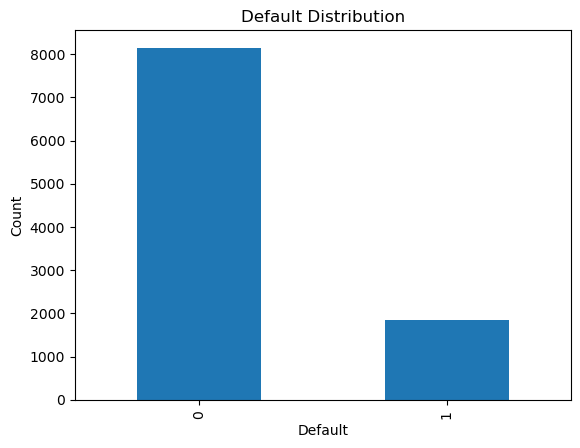

In [9]:
import matplotlib.pyplot as plt

df["default"].value_counts().plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

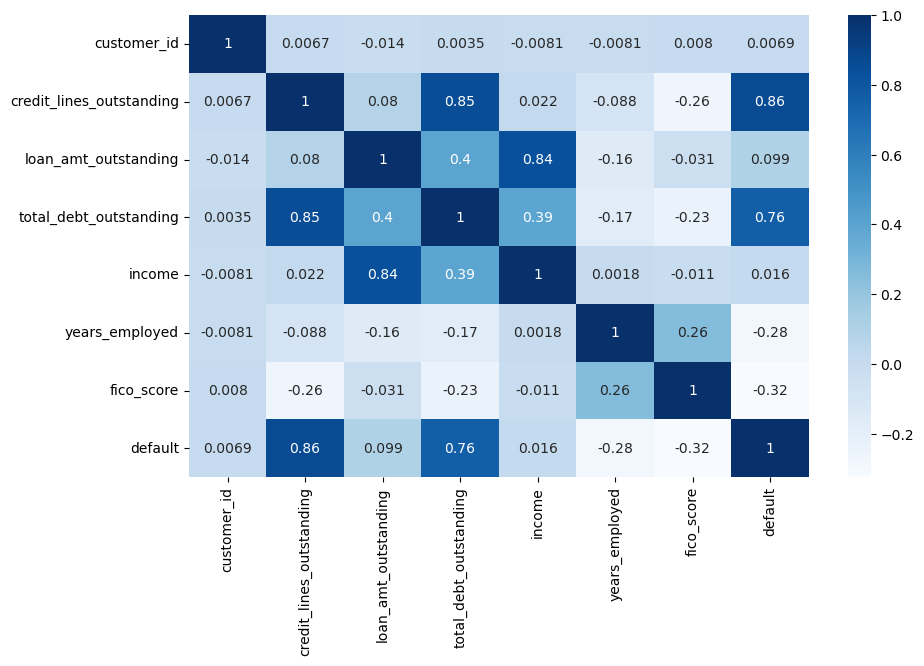

In [10]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),annot=True,cmap="Blues")

plt.show()

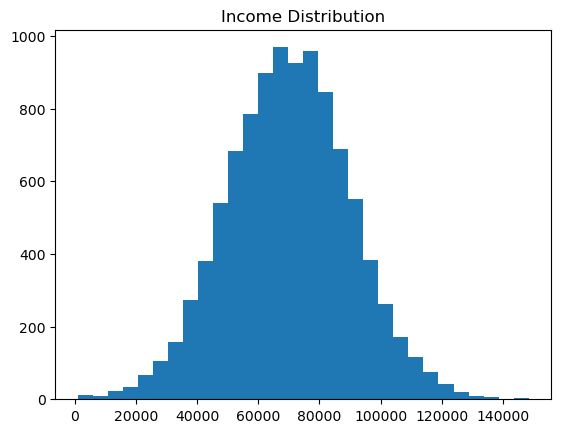

In [11]:
plt.hist(df["income"],bins=30)

plt.title("Income Distribution")

plt.show()

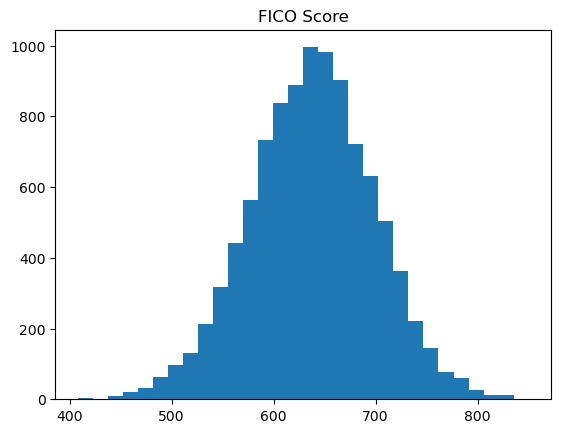

In [12]:
plt.hist(df["fico_score"],bins=30)

plt.title("FICO Score")

plt.show()

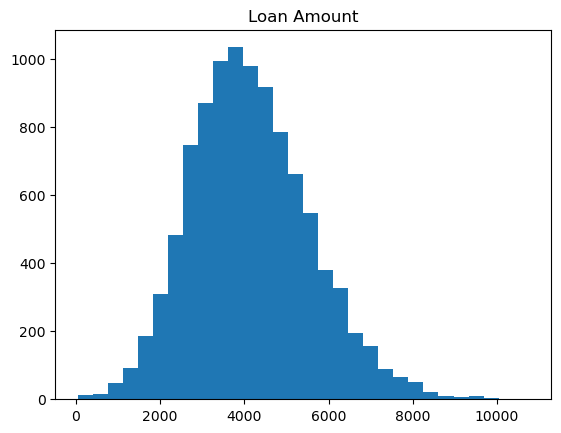

In [13]:
plt.hist(df["loan_amt_outstanding"],bins=30)

plt.title("Loan Amount")

plt.show()

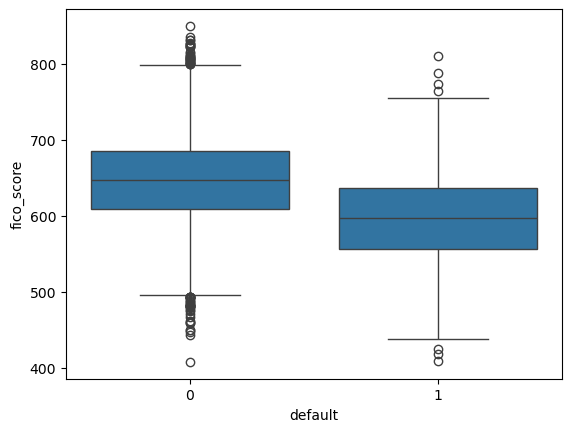

In [14]:
sns.boxplot(x="default",y="fico_score",data=df)

plt.show()

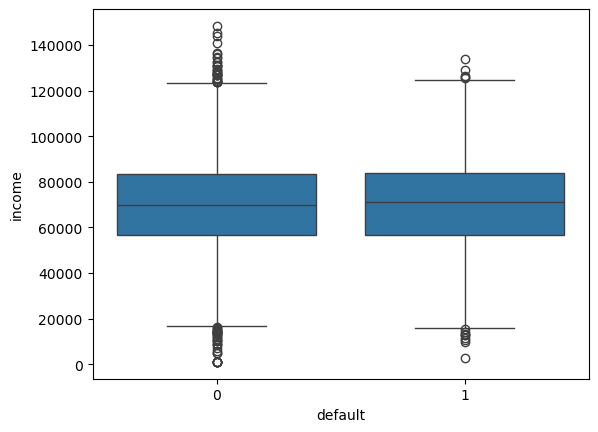

In [15]:
sns.boxplot(x="default",y="income",data=df)

plt.show()

In [16]:
y = df["default"]

In [17]:
X = df.drop(["default","customer_id"],axis=1)

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [20]:
prediction=model.predict(X_test)

In [21]:
probability=model.predict_proba(X_test)

In [22]:
pd_probability=probability[:,1]

In [23]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,prediction)

0.997

In [24]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,prediction)

print(cm)

[[1652    0]
 [   6  342]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       1.00      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,pd_probability)

np.float64(0.9999913027747628)

In [27]:
importance=pd.DataFrame({

"Feature":X.columns,

"Coefficient":model.coef_[0]

})

importance.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
0,credit_lines_outstanding,7.301546
2,total_debt_outstanding,0.001428
1,loan_amt_outstanding,0.000479
3,income,-0.000318
5,fico_score,-0.034159
4,years_employed,-2.817704


In [29]:
X_test = X_test.copy()

X_test["PD"] = pd_probability

X_test["Expected_Loss"] = (
    X_test["PD"] *
    0.90 *
    X_test["loan_amt_outstanding"]
)

X_test.head()

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,PD,Expected_Loss
6252,2,3584.844437,7708.784716,72005.83951,8,593,2.372962e-13,7.656030e-10
4684,3,5821.006507,16345.025390,80431.47019,6,634,1.102742e-03,5.777162e+00
1731,5,5343.193215,30614.603030,86303.95374,4,607,1.000000e+00,4.808874e+03
4742,0,1468.268561,1369.352513,28621.64224,5,621,8.044237e-15,1.062999e-11
4521,1,3519.975193,9027.320474,69844.46479,6,650,8.099339e-14,2.565852e-10


In [30]:
def expected_loss(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score
):

    data = pd.DataFrame({

        "credit_lines_outstanding":[credit_lines_outstanding],

        "loan_amt_outstanding":[loan_amt_outstanding],

        "total_debt_outstanding":[total_debt_outstanding],

        "income":[income],

        "years_employed":[years_employed],

        "fico_score":[fico_score]

    })

    pd_value = model.predict_proba(data)[0][1]

    expected_loss = pd_value * 0.90 * loan_amt_outstanding

    return pd_value, expected_loss

In [31]:
# EXAMPLE
pd_value, loss = expected_loss(

credit_lines_outstanding=2,

loan_amt_outstanding=25000,

total_debt_outstanding=40000,

income=65000,

years_employed=5,

fico_score=700

)

print("Probability of Default:", pd_value)

print("Expected Loss:", loss)

Probability of Default: 0.9999999999999987
Expected Loss: 22499.99999999997
